# Rayleigh–Bénard Convection — Two-Way Thermal-Flow Coupling

The [previous tutorial](06_buoyant_cavity.ipynb) coupled flow and temperature two ways in a *vertical* cavity: hot left wall, cold right wall, buoyancy acting sideways against gravity. This notebook uses the same two-way coupling machinery for the other classic configuration — **Rayleigh–Bénard convection**: a fluid layer heated from below and cooled from above, with gravity pointing straight down through the temperature gradient. Hot fluid at the bottom is lighter than the fluid above it, so it wants to rise; cold fluid at the top wants to sink. Above a critical temperature difference, this instability organizes itself into **convection rolls** — for the wide, shallow cavity used here, a pair of counter-rotating cells is what actually appears (see the plot at the end of Step 5).

**Why this is a genuinely different kind of coupling.** In the one-way thermal tutorials, recovering the flow's velocity and handing it to the thermal solver was enough — the flow's own equations never referenced the temperature. Here the flow equations gain an extra term, the **buoyancy force**, that depends on the local temperature. That force has to be recomputed from the *current* temperature field and fed back into the flow's collision step, every time step, for the two solvers to stay coupled in both directions.

**The physics in one line, via the Boussinesq approximation.** Temperature differences are assumed small enough that density is treated as constant everywhere *except* in the one place it multiplies gravity, giving a body force per unit mass

$$
\mathbf{F}_{\text{buoyancy}} = \mathbf{g}\,\beta\,(T - T_{\text{ref}}),
$$

where $\mathbf{g}$ is the (vector) gravitational acceleration, $\beta$ is the thermal expansion coefficient, and $T_{\text{ref}}$ is a reference temperature at which the fluid is neutrally buoyant. Fluid warmer than $T_{\text{ref}}$ is pushed the way $\mathbf{g}$ points; fluid colder than $T_{\text{ref}}$ is pushed the other way. Here $\mathbf{g}$ points in $+y$ (see Step 2), so fluid heated from below rises. This is exactly the force this notebook injects into the flow solver's collision step, computed fresh from the scalar solver's temperature field at every step.

**The dimensionless numbers that describe this problem:**

$$
Re = \frac{UL}{\nu}, \qquad
Pr = \frac{\nu}{\alpha}, \qquad
Gr = \frac{g\beta\Delta T L^3}{\nu^2}, \qquad
Ra = Gr\cdot Pr, \qquad
Ri = \frac{Gr}{Re^2} = \frac{g\beta\Delta T\,L}{U^2}
$$

with $U$ a characteristic velocity, $L$ a characteristic length, $\nu$ the kinematic viscosity, $\alpha$ the thermal diffusivity, and $\Delta T = T_s - T_\infty$ a characteristic temperature difference. Rayleigh–Bénard convection is normally characterized purely by the **Rayleigh number** $Ra$ (buoyant vs. combined viscous/thermal diffusion): above a critical $Ra_c \approx 1708$ (no-slip top/bottom, infinite layer), the quiescent conducting state becomes unstable and rolls form. This notebook additionally imposes a small vertical velocity on the side walls (Step 3), which is *not* part of the classical problem — it's there purely to seed asymmetry and get the rolls moving in a predictable direction instead of waiting on numerical noise to break the symmetry. That extra shear is why $Ri$ (buoyancy vs. imposed inertial forcing) is still tracked here rather than working with $Ra$ alone, even though buoyancy is what actually organizes the flow into rolls.
</cell id="0b4892ce">


---
## Step 1 — Imports


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import xlb
import xlb.velocity_set
from xlb.compute_backend import ComputeBackend
from xlb.grid import grid_factory
from xlb.helper import omega_from_diffusivity
from xlb.operator.boundary_condition import (
    EquilibriumBC,
    HalfwayBounceBackBC,
    ScalarDirichletBC,
    ScalarNeumannBC,
)
from xlb.operator.macroscopic import Macroscopic, ZeroMoment
from xlb.operator.stepper import IncompressibleNavierStokesStepper, ThermalStepper
from xlb.precision_policy import PrecisionPolicy

FIG_DIR = Path("figures/rayleighbenard")
FIG_DIR.mkdir(parents=True, exist_ok=True)

---
## Step 2 — Parameters, and turning the Richardson number into a gravity vector

The cavity is a wide, shallow rectangle — width $N$, height $N\cdot$`H_to_L_ratio` — at $Re=2000$, $Pr=0.71$ (air), and $Ri=5$. A shallow aspect ratio (2:1 here) is what lets more than one convection roll fit side by side; a square cavity at the same parameters would instead settle into a single roll. As in the vertical-cavity notebook, two independent stencils are used: the flow keeps the default D2Q9, while the scalar (temperature) uses the cheaper D2Q5, since it only ever needs to recover a single scalar moment.

**From $Ri$ to a gravity vector.** Rather than picking $g$ and $\beta$ separately, it is more convenient to choose $Ri$ directly, since only the product $g\beta\Delta T$ ever enters the Boussinesq force. Solving the definition of $Ri$ above for that product,

$$
g\,\beta\,\Delta T = \frac{Ri\cdot U^2}{L},
$$

and taking the maximum possible temperature difference $\beta\Delta T \equiv 1$ (i.e. absorbing $\beta$ and $\Delta T$ into the definition of $g$, since the Boussinesq force only ever appears as the product $g\beta\Delta T\cdot(T-T_{\text{ref}})/\Delta T$) gives a single effective gravitational acceleration in lattice units, $g = Ri\cdot U^2/L$. This is the scalar magnitude used to build the gravity **vector** `g = np.array([...])` below.

One sign convention is worth flagging, since it is easy to get backwards and produces a simulation that runs without error but pushes the temperature field the wrong way: `ExactDifference` (the force-injection operator used by `ForcedCollision`, see Step 3) applies the force with an internal sign such that a **positive** `g` component here produces buoyancy acting in the **positive** coordinate direction. Since "up" in image coordinates (`imshow(..., origin="lower")`, used throughout the plots) is the **positive** $y$ direction, a positive `g[1]` correctly makes warmer-than-`T_ref` fluid — heated from the bottom wall, see Step 4 — rise on screen, which is exactly the Rayleigh–Bénard setup.
</cell id="c0361db0">


In [2]:
N = 256
H_to_L_ratio = 0.25
grid_shape = (N, int(N * H_to_L_ratio))
precision_policy = PrecisionPolicy.FP64FP64
compute_backend = ComputeBackend.JAX

# The default velocity set must be the flow's D2Q9
flow_velocity_set = xlb.velocity_set.D2Q9(precision_policy=precision_policy, compute_backend=compute_backend)
xlb.init(
    velocity_set=flow_velocity_set,
    default_backend=compute_backend,
    default_precision_policy=precision_policy,
)

# The scalar keeps its own, cheaper stencil
thermal_velocity_set = xlb.velocity_set.D2Q5(precision_policy=precision_policy, compute_backend=compute_backend)

Pr = 0.71
Re = 2000
Pe = Re * Pr
Ri = 5

prescribed_vel = 0.05
clength = grid_shape[0] - 1

viscosity = prescribed_vel * clength / Re
omega_flow = 1.0 / (3.0 * viscosity + 0.5)

diffusivity = prescribed_vel * clength / Pe
omega_thermal = omega_from_diffusivity(diffusivity)

# There is a minus sign inside the forced collision operator, so we need to flip the sign of the force vector to get a positive buoyancy force in the upward direction.
g = np.array([0, Ri * prescribed_vel**2 / (grid_shape[0] - 1)])
grid = grid_factory(grid_shape, compute_backend=compute_backend)

No GPU support is available; CPU fallback will be used.


---
## Step 3 — Flow boundary conditions, and why the buoyancy force is passed at call time

**Boundary conditions.** The top and bottom of the cavity — which double as the hot and cold thermal boundaries in Step 4 — are plain no-slip walls (`HalfwayBounceBackBC`): the physical top and bottom plates don't move, only their temperature differs. The left and right side walls are given a small imposed vertical velocity via `EquilibriumBC` instead of being left as no-slip. Classical Rayleigh–Bénard has no imposed velocity anywhere ($Ri \to \infty$); the small shear added here just breaks the left-right symmetry so the rolls form in a predictable, repeatable direction instead of depending on whatever numerical noise happens to seed the instability first.

**Why `force_vector` is passed at construction time even though it changes every step.** `IncompressibleNavierStokesStepper` only wraps its collision operator in `ForcedCollision` (the machinery that knows how to inject a body force at all) if `force_vector` is given when the stepper is built. The array passed here, built from the constant `g` alone, is therefore only a **placeholder**: it fixes the force field's shape and dtype once and for all, and tells the stepper "this simulation has a force." It is *not* the array that does the buoyancy physics — that one is recomputed from the temperature field inside the time loop (Step 5) and passed directly into the stepper's `__call__` as an ordinary function argument on every step.

This distinction matters more than it looks like it should, because of how JAX's JIT compilation works. `IncompressibleNavierStokesStepper.__call__` is JIT-compiled with `self` as a **static** argument, so anything stored as `self.something` (including `flow_stepper.collision.force_vector`, if you were to reassign it) gets baked into the compiled trace as a *compile-time constant* the first time the stepper runs. Reassigning that attribute afterwards silently does nothing at all — later calls keep using the value captured by the very first trace. Passing the force as a normal call argument instead makes it a *traced* value, exactly like `f_0` or `omega`, so JAX picks up the new array on every call without needing to recompile, as long as its shape and dtype don't change. This one design choice is what makes two-way coupling actually work here, as opposed to silently reproducing one-way coupling with a permanently frozen, near-zero force — a failure mode that is easy to hit and gives no error, only a simulation that quietly does the wrong thing.
</cell id="1618a390">


In [3]:
box = grid.bounding_box_indices()
box_no_edge = grid.bounding_box_indices(remove_edges=True)

left_wall = box_no_edge["left"]
right_wall = box_no_edge["right"]
noslip_walls = [box["bottom"][i] + box["top"][i] for i in range(flow_velocity_set.d)]

import jax.numpy as jnp

# This is only a placeholder, uniform force (built from `g` alone) so that
# IncompressibleNavierStokesStepper knows to wrap its collision operator in
# ForcedCollision, and so the shape/dtype of the force array is fixed once and for all.
# The REAL, temperature-dependent Boussinesq force is computed fresh every step in the
# time loop below and passed directly to the stepper call -- it is not built by mutating
# this array. See the time-loop cell for why that distinction matters.
buoyancy_force = jnp.zeros((flow_velocity_set.d, *grid_shape))
buoyancy_force = buoyancy_force.at[0].set(g[0])
buoyancy_force = buoyancy_force.at[1].set(g[1])

flow_stepper = IncompressibleNavierStokesStepper(
    grid=grid,
    boundary_conditions=[
        HalfwayBounceBackBC(indices=noslip_walls),
        EquilibriumBC(rho=1.0, u=(0.0, prescribed_vel), indices=left_wall),
        EquilibriumBC(rho=1.0, u=(0.0, prescribed_vel), indices=right_wall),
    ],
    collision_type="BGK",
    force_vector=buoyancy_force,
)

f_0, f_1, bc_mask, missing_mask = flow_stepper.prepare_fields()

registered bc HalfwayBounceBackBC_294110711 with id 1
WARNING! Assuming no-slip condition for BC type = HalfwayBounceBackBC!
registered bc EquilibriumBC_298912628 with id 2
registered bc EquilibriumBC_294090429 with id 3
Warp 1.16.0 initialized:
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/rivas/Library/Caches/warp/1.16.0


---
## Step 4 — Thermal boundary conditions

The bottom wall is held at the hot temperature ($T=1$) and the top wall at the reference/cold temperature ($T_{\text{ref}}=0$), both via `ScalarDirichletBC` — this is the actual Rayleigh–Bénard temperature gradient, aligned with gravity. The left and right walls are adiabatic (`ScalarNeumannBC(flux=0.0)`): they only affect the flow, through the imposed shear from Step 3, not the temperature. This is the same Dirichlet/Neumann pattern used in the earlier cavity tutorials — see those notebooks for why the wall index sets are built the way they are (which faces use the full bounding box vs. `remove_edges=True`, and why that choice matters at the corners).
</cell id="81dd9fcc">


In [4]:
hot = box["bottom"]
cold = box["top"]
insulated = [box_no_edge["left"][i] + box_no_edge["right"][i] for i in range(thermal_velocity_set.d)]

T_ref = 0.0

thermal_stepper = ThermalStepper(
    grid=grid,
    boundary_conditions=[
        ScalarDirichletBC(value=1.0, indices=hot),
        ScalarDirichletBC(value=T_ref, indices=cold),
        ScalarNeumannBC(flux=0.0, indices=insulated),
    ],
    velocity_set=thermal_velocity_set,
)

g_0, g_1, bc_mask_thermal, missing_mask_thermal = thermal_stepper.prepare_fields(phi_init=0.0)
u, source = thermal_stepper.prepare_aux_fields()

registered bc ScalarDirichletBC_298917118 with id 4
registered bc ScalarDirichletBC_298410796 with id 5
registered bc ScalarNeumannBC_298911857 with id 6


---
## Step 5 — The two-way coupled time loop

Each step now does four things, one more than the one-way tutorials:

1. Advance the **flow**, using the buoyancy force computed from **last** step's temperature (there is necessarily a one-step lag: the force needs a temperature field, and the temperature field needs the flow's velocity from the *previous* step to advect it — this explicit, lagged coupling is the standard way to couple two LBM solvers without solving a joint nonlinear system at every step).
2. Recover the velocity and hand it to the thermal solver.
3. Advance the **temperature**, advected by that velocity.
4. Recover the new temperature and build **next** step's buoyancy force, $g_\alpha\,(T-T_{\text{ref}})$ component-wise — this is passed directly to `flow_stepper(...)` at the top of the next iteration, not stored back onto the stepper object (see Step 3 for why that distinction is essential rather than stylistic).

The plot every `report_every` steps shows the velocity field with streamlines and the temperature field with isotherms. Watch the velocity panel for the roll pattern to emerge and stabilize — starting from a quiescent, uniformly-cold fluid, it takes a while for the instability to grow, and the number of rolls that ultimately forms depends on the cavity's aspect ratio.
</cell id="ffdc5a58">


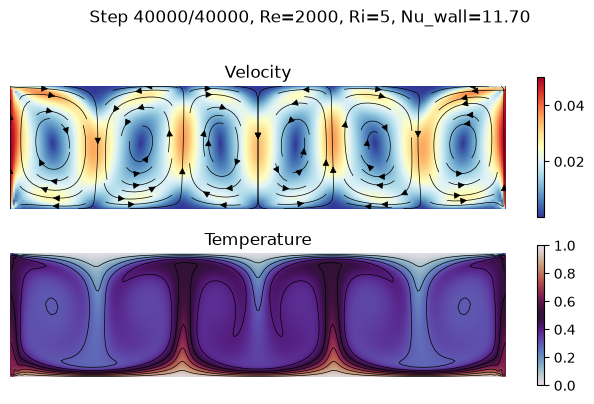

In [5]:
from IPython.display import clear_output as clc

macroscopic = Macroscopic()
zero_moment = ZeroMoment(
    velocity_set=thermal_velocity_set,
    precision_policy=precision_policy,
    compute_backend=compute_backend,
)

num_steps = 40000
report_every = 5000
H = grid_shape[1] - 1
delta_T = 1.0 - T_ref

nu_history = []  # (step, Nu_wall), sampled every `report_every` steps -- used later to
                 # check the run has settled into a statistically steady convective state,
                 # rather than trusting a single, possibly noisy, instantaneous snapshot.

for i in range(num_steps):

    # 1. Advance the flow
    f_0, f_1 = flow_stepper(f_0, f_1, bc_mask, missing_mask, omega_flow, i, buoyancy_force)
    f_0, f_1 = f_1, f_0

    # 2. Recover the velocity and hand it to the scalar
    _, u = macroscopic(f_0)

    # 3. Advance the scalar, advected by that velocity
    g_0, g_1 = thermal_stepper(
        g_0, g_1, u, source, bc_mask_thermal, missing_mask_thermal, omega_thermal, i
    )
    g_0, g_1 = g_1, g_0

    # 4. Recover temperature and build the Boussinesq force for THIS step, as a plain
    #    array passed to the stepper call itself (see Step 3 for why -- not by mutating
    #    `flow_stepper.collision.force_vector`).
    T = zero_moment(g_0)[0]
    buoyancy_force = jnp.zeros((flow_velocity_set.d, *grid_shape))
    buoyancy_force = buoyancy_force.at[0].set(g[0] * (T - T_ref))
    buoyancy_force = buoyancy_force.at[1].set(g[1] * (T - T_ref))

    # 5. Every `report_every` steps: record the wall-gradient Nusselt number at the hot
    #    (bottom) wall (sampled sparsely, not every step, since pulling a JAX array to the
    #    host forces a device sync) and make a plot.
    fig_size = 8
    nrows = 2
    ncols = 1
    if (i+1) % report_every == 0:
        T_host = np.asarray(T)
        Nu_wall_step = float(-(T_host[:, 1].mean() - 1.0) * H / delta_T)
        nu_history.append((i + 1, Nu_wall_step))

        fig, axs = plt.subplots(nrows, ncols, figsize=(fig_size * ncols, fig_size * nrows * H_to_L_ratio))

        axs[0].set_title("Velocity")
        c = axs[0].imshow(np.linalg.norm(u, axis=0).T, origin="lower", cmap="RdYlBu_r")

        if i == num_steps - 1:
            axs[0].streamplot(np.arange(0, grid_shape[0], 1), np.arange(0, grid_shape[1], 1), u[0].T, u[1].T, color="k", density=1.0, linewidth=0.5)

        axs[0].set_xlim(0, grid_shape[0]-1)
        axs[0].set_ylim(0, grid_shape[1]-1)
        fig.colorbar(c, ax=axs[0], aspect = 20)

        axs[1].set_title("Temperature")
        c = axs[1].imshow(T_host.T, origin="lower", cmap="twilight", vmin=0, vmax=1)
        xg, yg = np.meshgrid(np.arange(0, grid_shape[0], 1), np.arange(0, grid_shape[1], 1))
        axs[1].contour(xg, yg, T_host.T, levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], colors="k", linewidths=0.5)
        fig.colorbar(c, ax=axs[1], aspect = 20)

        for ax in axs:
            ax.axis('off')

        fig.suptitle(f"Step {i+1}/{num_steps}, Re={Re}, Ri={Ri}, Nu_wall={Nu_wall_step:.2f}", y=1.05)

        plt.show()
        clc(wait=True)
        plt.close(fig)